# Inverse Design of Bloch Surface Waves

In this notebook, we study the excitation of **Bloch Surface Waves (BSW)** on a dielectric multilayer structure. We use Gradient Descent via PyTorch and the `nannos` RCWA solver to optimize the local field enhancement at the surface.

### Problem Statement
**Objective:** Maximize the electric field enhancement $|E|^2$ (for TE) or magnetic field enhancement $|H|^2$ (for TM) at the interface between a dielectric multilayer and air.

**Structure:** A 1D photonic crystal (Bragg stack) consisting of 20 alternating layers of Silica ($SiO_2$) and Titania ($TiO_2$), deposited on a high-index prism substrate.

**Excitation:** Total Internal Reflection (TIR) condition from the prism side.

**Optimization Parameters:**
- Thickness of each of the 20 layers.
- The incident angle $\theta$.

In [ ]:
# Installation check for nannos (Colab compatibility)
try:
    import nannos as nn
    print("nannos already installed.")
except ImportError:
    print("Installing nannos...")
    !pip install nannos
    import nannos as nn

/opt/miniconda3/envs/rcwa/lib/python3.12/site-packages/nannos/utils/jupyter.py:16: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


nannos already installed.


## 1. Libraries and Configuration

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import nannos as nn

# Set nannos backend to torch
nn.set_backend("torch")

# Set default dtype to float64 for high precision
torch.set_default_dtype(torch.float64)

# Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#191919', 
    'axes.facecolor': '#191919', 
    'savefig.facecolor': '#191919',
    'grid.alpha': 0.3
})

## 2. Auxiliary Functions

In [ ]:
def compute_enhancement(thicknesses, theta, wl, polarization, n_prism, n_air, n_low, n_high):
    """
    Computes the surface field enhancement using nannos.
    """
    # Dummy lattice for 1D simulation
    lattice = nn.Lattice([[1.0, 0.0], [0.0, 1.0]])
    
    # Build the stack
    # Light is incident from the Superstrate (Prism)
    superstrate = lattice.Layer("Prism", epsilon=n_prism**2)
    substrate = lattice.Layer("Air", epsilon=n_air**2)
    
    stack = [superstrate]
    for i, d in enumerate(thicknesses):
        # Alternate Silica (Low) and Titania (High)
        eps = n_low**2 if i % 2 == 0 else n_high**2
        # Ensure positive thickness for physical validity
        d_phys = torch.abs(d) + 1.0 
        layer = lattice.Layer(f"Layer_{i}", thickness=d_phys, epsilon=eps)
        stack.append(layer)
    stack.append(substrate)
    
    # Plane wave configuration (theta, phi, polarization)
    # polarization: 0 for TE (S), 90 for TM (P)
    # nannos uses psi=0 for TM, psi=90 for TE at phi=0
    psi = 90.0 if polarization == 0 else 0.0
    # Manually calculate wavevector for differentiability with respect to theta
    k0 = 2 * np.pi / wl
    kx = k0 * torch.sin(torch.deg2rad(theta))
    kz = k0 * torch.cos(torch.deg2rad(theta))
    pw = nn.PlaneWave(wavelength=wl, angles=(theta.detach().item(), 0.0, psi))
    pw.wavevector = torch.stack([kx, torch.tensor(0.0), kz])
    
    # Simulation with 1 harmonic (pure TMM for 1D stack)
    sim = nn.Simulation(stack, pw, nh=1)
    
    # Compute field at the top surface (interface with Air)
    # The last layer index is len(stack)-1
    E, H = sim.get_field_grid(len(stack)-1, z=0.0, shape=(1, 1))
    
    if polarization == 0: # TE (Ey component is transverse for phi=0)
        intensity = torch.abs(E[1, 0, 0, 0])**2
    else: # TM (Hy component is transverse for phi=0)
        intensity = torch.abs(H[1, 0, 0, 0])**2
        
    return intensity, torch.abs(thicknesses) + 1.0

def initialize_optimization(num_layers, wl, polarization, lr=0.5):
    # Initial thicknesses: roughly Bragg-like (~100nm)
    init_d = torch.ones(num_layers) * 100.0
    thicknesses = torch.nn.Parameter(init_d)
    
    # Initial angle: near TIR (theta_c ~ 42 deg for n=1.5)
    theta = torch.nn.Parameter(torch.tensor(50.0))
    
    optimizer = torch.optim.Adam([thicknesses, theta], lr=lr)
    history = {'loss': [], 'theta': [], 'thicknesses': []}
    
    return thicknesses, theta, optimizer, history

def log_metrics(step, num_iterations, intensity, theta, d_phys, history):
    history['loss'].append(intensity.item())
    history['theta'].append(theta.item())
    history['thicknesses'].append(d_phys.detach().numpy().copy())
    
    if (step + 1) % max(1, (num_iterations // 50)) == 0:
        print(f"Step {step+1:03d} | Angle: {theta.item():.2f}° | Intensity: {intensity.item():.4f}")

## 3. Optimization Loop

In [4]:
# Physical constants and configuration
wl = 633.0  # nm (HeNe Laser)
n_prism = 1.51  # BK7 Glass
n_air = 1.0
n_low = 1.45 + 1j * 1e-5  # SiO2
n_high = 2.4 + 1j * 1e-4  # TiO2

num_layers = 10
num_iterations = 4000
polarization = 1  # 0=TE, 1=TM
lr = 1e-1

thicknesses, theta, optimizer, history = initialize_optimization(
    num_layers, wl, polarization, lr
)

# Critical angle for TIR (Total Internal Reflection)
theta_c = torch.rad2deg(torch.asin(torch.tensor(n_air / n_prism))) + 1.0
mu = 1.0e-3  # Barrier coefficient

print(f"Starting optimization for {num_layers} layers...")
print(f"Critical angle: {theta_c.item():.2f}°")

for step in range(num_iterations):
    optimizer.zero_grad()

    intensity, d_phys = compute_enhancement(
        thicknesses, theta, wl, polarization, n_prism, n_air, n_low, n_high
    )

    # Maximize intensity s.t. theta > theta_c
    # Penalty: -mu * log(theta - theta_c)
    penalty = -mu * torch.log(theta - theta_c)
    loss = -intensity + penalty

    loss.backward()
    optimizer.step()

    log_metrics(step, num_iterations, intensity, theta, d_phys, history)

print("Optimization complete.")
d_final = d_phys.detach()
theta_final = theta.detach()

Starting optimization for 10 layers...
Critical angle: 42.47°
Step 080 | Angle: 74.01° | Intensity: 0.8798
Step 160 | Angle: 79.10° | Intensity: 1.9635
Step 240 | Angle: 85.41° | Intensity: 5.5158
Step 320 | Angle: 85.72° | Intensity: 8.9727
Step 400 | Angle: 85.54° | Intensity: 12.4459
Step 480 | Angle: 85.35° | Intensity: 15.8303
Step 560 | Angle: 85.17° | Intensity: 19.7394
Step 640 | Angle: 85.01° | Intensity: 23.1406
Step 720 | Angle: 84.84° | Intensity: 27.3874
Step 800 | Angle: 84.69° | Intensity: 29.5892
Step 880 | Angle: 84.54° | Intensity: 33.6202
Step 960 | Angle: 84.42° | Intensity: 37.0394
Step 1040 | Angle: 84.31° | Intensity: 40.1023
Step 1120 | Angle: 84.20° | Intensity: 42.9992
Step 1200 | Angle: 84.09° | Intensity: 45.7302
Step 1280 | Angle: 84.00° | Intensity: 48.3066
Step 1360 | Angle: 83.91° | Intensity: 50.7355
Step 1440 | Angle: 83.82° | Intensity: 53.0249
Step 1520 | Angle: 83.74° | Intensity: 55.1831
Step 1600 | Angle: 83.66° | Intensity: 57.2183
Step 1680 | An

## 4. Results Visualization

### 4.1 Optimization History

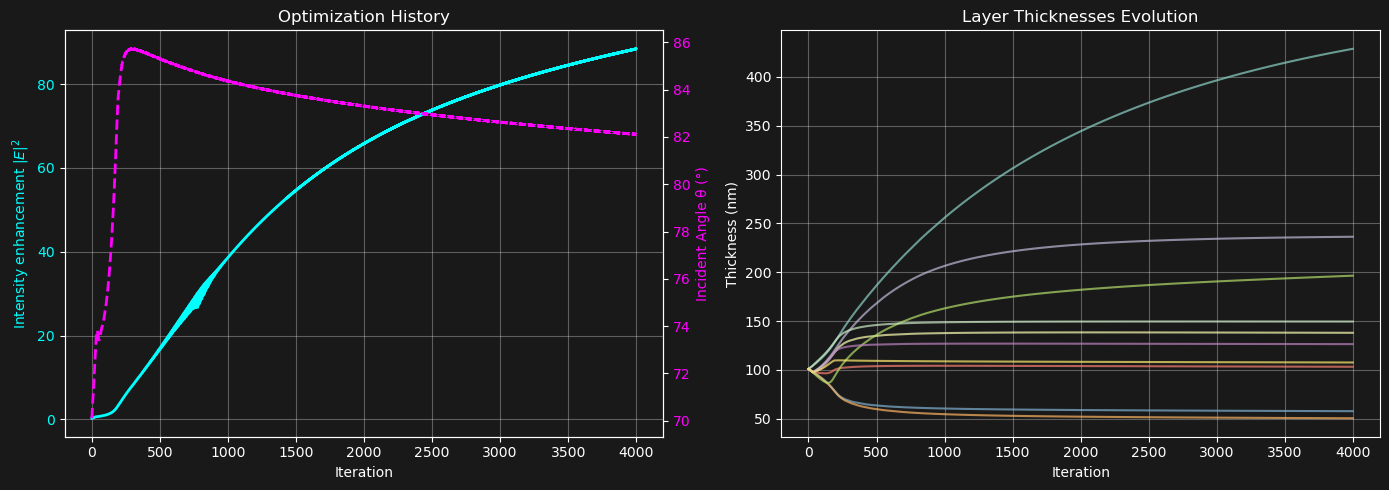

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Loss and Angle
ax1 = axes[0]
ax1.plot(history['loss'], color='cyan', lw=2, label='Intensity')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Intensity enhancement $|E|^2$', color='cyan')
ax1.tick_params(axis='y', labelcolor='cyan')
ax1.set_title('Optimization History')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(history['theta'], color='magenta', lw=2, ls='--', label='Angle')
ax2.set_ylabel('Incident Angle θ (°)', color='magenta')
ax2.tick_params(axis='y', labelcolor='magenta')

# Panel 2: Geometrical Parameters
d_hist = np.array(history['thicknesses'])
for i in range(num_layers):
    axes[1].plot(d_hist[:, i], alpha=0.7)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Thickness (nm)')
axes[1].set_title('Layer Thicknesses Evolution')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 4.2 Angular Spectrum
We check the reflection spectrum around the optimized angle to confirm the presence of a sharp BSW resonance.

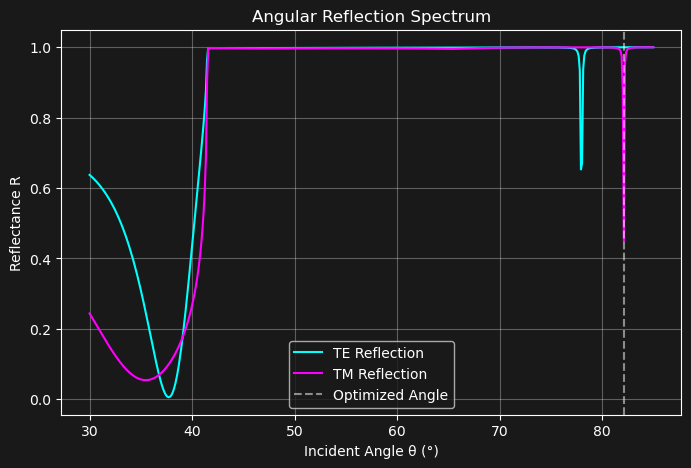

In [6]:
def get_angular_spectrum(thicknesses, wl, n_prism, n_air, n_low, n_high, pol):
    angles = np.linspace(30, 85, 500)
    R_list = []
    
    lattice = nn.Lattice([[1.0, 0.0], [0.0, 1.0]])
    superstrate = lattice.Layer("Prism", epsilon=n_prism**2)
    substrate = lattice.Layer("Air", epsilon=n_air**2)
    stack = [superstrate]
    for i, d in enumerate(thicknesses):
        eps = n_low**2 if i % 2 == 0 else n_high**2
        stack.append(lattice.Layer(f"L{i}", thickness=d, epsilon=eps))
    stack.append(substrate)

    for a in angles:
        pw = nn.PlaneWave(wavelength=wl, angles=(a, 0.0, pol))
        sim = nn.Simulation(stack, pw, nh=1)
        R, T = sim.diffraction_efficiencies(orders=False)
        R_list.append(R.item())
    
    return angles, np.array(R_list)

angles_te, R_te = get_angular_spectrum(d_final, wl, n_prism, n_air, n_low, n_high, 90)
angles_tm, R_tm = get_angular_spectrum(d_final, wl, n_prism, n_air, n_low, n_high, 0)

plt.figure(figsize=(8, 5))
plt.plot(angles_te, R_te, color='cyan', label='TE Reflection')
plt.plot(angles_tm, R_tm, color='magenta', label='TM Reflection')
plt.axvline(theta_final.item(), color='white', ls='--', alpha=0.5, label='Optimized Angle')
plt.xlabel('Incident Angle θ (°)')
plt.ylabel('Reflectance R')
plt.title('Angular Reflection Spectrum')
plt.legend()
plt.grid(True)
plt.show()

### 4.3 Field Distribution (Z-Cross Section)
We visualize the buildup of the evanescent field at the surface.

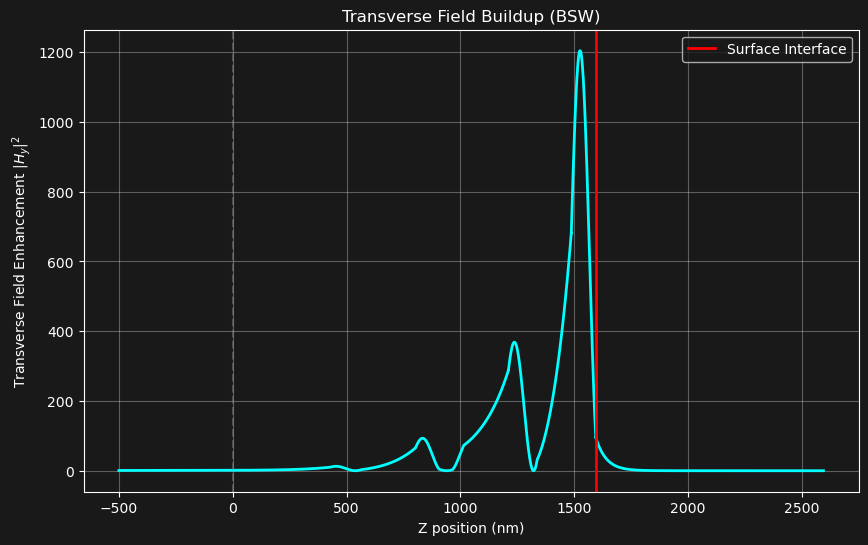

In [7]:
# Setup simulation for field mapping
lattice = nn.Lattice([[1.0, 0.0], [0.0, 1.0]])
superstrate = lattice.Layer("Prism", epsilon=n_prism**2)
substrate = lattice.Layer("Air", epsilon=n_air**2)
stack = [superstrate]
for i, d in enumerate(d_final):
    eps = n_low**2 if i % 2 == 0 else n_high**2
    stack.append(lattice.Layer(f"L{i}", thickness=d, epsilon=eps))
stack.append(substrate)

psi = 90.0 if polarization == 0 else 0.0
pw = nn.PlaneWave(wavelength=wl, angles=(theta_final, 0.0, psi))
sim = nn.Simulation(stack, pw, nh=1)

# Create Z-grid
total_thickness = sum(d_final).item()
z_prism = np.linspace(-500, 0, 100)        # Inside Prism
z_air = np.linspace(0, 1000, 200)          # Inside Air

fields = []
z_plot = []
current_z = 0

# 1. Prism
E, H = sim.get_field_grid(0, z=z_prism, shape=(1, 1))
fields.append(torch.abs(E[1, 0, 0, :])**2 if polarization == 0 else torch.abs(H[1, 0, 0, :])**2)
z_plot.extend(z_prism)

# 2. Multilayer
for i in range(1, len(stack)-1):
    d = d_final[i-1].item()
    z_layer = np.linspace(0, d, 50)
    E, H = sim.get_field_grid(i, z=z_layer, shape=(1, 1))
    fields.append(torch.abs(E[1, 0, 0, :])**2 if polarization == 0 else torch.abs(H[1, 0, 0, :])**2)
    z_plot.extend(z_layer + current_z)
    current_z += d

# 3. Air
E, H = sim.get_field_grid(len(stack)-1, z=z_air, shape=(1, 1))
fields.append(torch.abs(E[1, 0, 0, :])**2 if polarization == 0 else torch.abs(H[1, 0, 0, :])**2)
z_plot.extend(z_air + current_z)

plt.figure(figsize=(10, 6))
plt.plot(z_plot, torch.cat(fields).numpy(), color='cyan', lw=2)
plt.axvline(0, color='gray', ls='--', alpha=0.5)
plt.axvline(current_z, color='red', ls='-', lw=2, label='Surface Interface')
plt.xlabel('Z position (nm)')
plt.ylabel('Transverse Field Enhancement $|E_y|^2$' if polarization == 0 else 'Transverse Field Enhancement $|H_y|^2$')
plt.title('Transverse Field Buildup (BSW)')
plt.legend()
plt.grid(True)
plt.show()